In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from src.preprocessing import process_store_data
from src.features import attach_store_data, make_features, make_targets
# NOTE: train_df['Open'] == 0 -> train_df['Sales'] = 0. This happens always
# TODO: Clusters on sales and/or holidays that occur together?


DATA_DIR = '../datasets/rossmann-store-sales'
STORE_FILE = os.path.join(DATA_DIR, 'store.csv')
TRAIN_FILE = os.path.join(DATA_DIR, 'train.csv')
TEST_FILE = os.path.join(DATA_DIR, 'test.csv')

FORECAST_HORIZON = 6*7 # We're forecasting daily for 6 weeks into the future
LAGS = [1, 2, 7, 30, 90, 182, 365]
DIFFS = [1, 30, 90, 182, 365]
ROLL_WINDOWS = { 7: 1, # window: lags
                30: [30, 90, 182, 365]}
HOLIDAY_WINDOWS = [-7, 0, 7]


In [2]:
df_train = pd.read_csv(TRAIN_FILE,
                       parse_dates=['Date'],
                       dtype={'StateHoliday': str} # 0 -> '0'
                       ).drop(['Customers'], axis=1)

# NOTE: train_df['Open'] == 0 -> train_df['Sales'] = 0.
# This happens always. 
# We'll model without this and apply the rule at the end.
df_train.loc[df_train['Open'] == 0, 'Sales'] = np.nan
df_train['Sales'] = (df_train
                     .groupby(["Store"], group_keys=False)
                     .apply(lambda g: g
                            .set_index("Date")["Sales"]
                            .interpolate(method="time"),
                            include_groups=False)
                     .reset_index(level=0, drop=True))
df_train.drop(['Open'], axis=1, inplace=True)

In [3]:
store_df = pd.read_csv(STORE_FILE)
store_df = process_store_data(store_df)
df_train_store = attach_store_data(df_train, store_df)

# TODO: Predict log-transformed sales?
df_features = make_features(df_train_store, lags=LAGS, roll_windows=ROLL_WINDOWS, diffs=DIFFS, holiday_windows=HOLIDAY_WINDOWS)
#targets = make_targets(df=df_train[['Date', 'Store', 'Sales']], horizon=FORECAST_HORIZON)

#test_df = pd.read_csv(TEST_FILE, index_col=0, parse_dates=['Date'])
#test_df = features.attach_store_data(test_df, store_df)

In [4]:
sales_df = df_train[['Date', 'Store', 'Sales']].copy()

promo_df = df_features[['Date', 'Store', 'Promo_counter']].copy()
promo2_df = df_features[['Date', 'Store', 'Promo2_counter']].copy()

df = pd.merge(sales_df, promo_df)
df = pd.merge(df, promo2_df)

In [5]:
df_p = (pd.pivot(df, index='Date', columns='Store', values='Sales').sort_index())  # Sorted from oldest to newest
promo_p = (pd.pivot(df, index='Date', columns='Store', values='Promo_counter').sort_index())  # Sorted from oldest to newest
promo2_p = (pd.pivot(df, index='Date', columns='Store', values='Promo2_counter').sort_index())  # Sorted from oldest to newest

df_p.head()

Store,1,2,3,4,5,6,7,8,9,10,...,1106,1107,1108,1109,1110,1111,1112,1113,1114,1115
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,20668.0,18727.0,18843.0,21643.0,23557.0,22885.0,22213.0,18592.0,16391.0,17264.0,...,5007.0,4649.0,5243.0,6905.000000,5838.000000,4771.0,4540.0,4297.0,3697.0,3697.0
2013-01-02,7094.0,7350.0,6757.0,6709.5,6662.0,7140.0,10954.0,9113.0,8937.0,10203.0,...,25737.0,24286.0,22835.0,19875.000000,18809.000000,16670.0,17559.0,19263.0,19495.0,19727.0
2013-01-03,19560.0,14013.0,8466.0,10882.0,10628.5,10375.0,8967.0,6886.0,7624.5,8363.0,...,10999.0,12174.0,11423.0,10742.000000,11694.000000,12268.0,9871.0,7474.0,7903.0,7852.0
2013-01-04,2854.0,4415.0,4639.0,3523.0,4647.0,4509.0,4027.0,3545.0,5381.0,5547.0,...,7473.0,7665.0,8969.0,8600.333333,8231.666667,7863.0,10564.0,12869.0,12881.0,13517.0
2013-01-05,5424.5,5724.0,3909.0,3939.0,3788.5,3638.0,5620.0,5495.0,5131.0,5888.0,...,7224.0,8096.0,5917.0,3738.000000,6745.000000,6096.0,5719.0,6679.0,8288.0,5571.0


In [61]:
df_p.shape

(942, 1115)

In [6]:
roll = df_p.rolling(window=91) # One quarter is roughly 91 days

ii = 0
for rolled in roll:
    ii += 1
    if ii == 91:
        break

In [10]:
rolled.head(5)

Store,1,2,3,4,5,6,7,8,9,10,...,1106,1107,1108,1109,1110,1111,1112,1113,1114,1115
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,20668.0,18727.0,18843.0,21643.0,23557.0,22885.0,22213.0,18592.0,16391.0,17264.0,...,5007.0,4649.0,5243.0,6905.000000,5838.000000,4771.0,4540.0,4297.0,3697.0,3697.0
2013-01-02,7094.0,7350.0,6757.0,6709.5,6662.0,7140.0,10954.0,9113.0,8937.0,10203.0,...,25737.0,24286.0,22835.0,19875.000000,18809.000000,16670.0,17559.0,19263.0,19495.0,19727.0
2013-01-03,19560.0,14013.0,8466.0,10882.0,10628.5,10375.0,8967.0,6886.0,7624.5,8363.0,...,10999.0,12174.0,11423.0,10742.000000,11694.000000,12268.0,9871.0,7474.0,7903.0,7852.0
2013-01-04,2854.0,4415.0,4639.0,3523.0,4647.0,4509.0,4027.0,3545.0,5381.0,5547.0,...,7473.0,7665.0,8969.0,8600.333333,8231.666667,7863.0,10564.0,12869.0,12881.0,13517.0
2013-01-05,5424.5,5724.0,3909.0,3939.0,3788.5,3638.0,5620.0,5495.0,5131.0,5888.0,...,7224.0,8096.0,5917.0,3738.000000,6745.000000,6096.0,5719.0,6679.0,8288.0,5571.0


In [91]:
import numpy as np
import pandas as pd

def slope(df: pd.DataFrame) -> pd.Series:
    """
    Computes the linear trend (slope) for each column in a rolling window.

    Parameters
    ----------
    rolled : pd.DataFrame
        A windowed subset of the original DataFrame, as passed by rolling.apply().

    Returns
    -------
    pd.Series
        A Series of slope values, one per column.
    """
    if len(df) < 2:
        # Not enough data to compute slope
        return pd.Series(np.nan, index=df.columns)

    # Create numeric time vector for regression (0, 1, ..., n-1)
    X = np.arange(len(df))
    X_mean = X.mean()
    den = np.sum((X - X_mean) ** 2)

    # Vectorized slope computation: cov(X, Y) / var(X)
    slopes = ( (df - df.mean()).mul(X - X_mean, axis=0).sum(axis=0) ) / den

    return slopes

<Axes: >

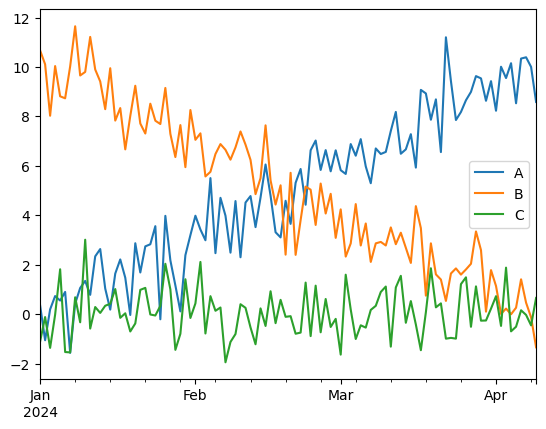

In [94]:
dates = pd.date_range("2024-01-01", periods=100)
df_test = pd.DataFrame({
    'A': np.linspace(0, 10, 100) + np.random.randn(100),   # upward trend
    'B': np.linspace(10, 0, 100) + np.random.randn(100),   # downward trend
    'C': np.random.randn(100)                              # no clear trend
}, index=dates)

df_test.plot()

In [95]:
slope(df_test)

A    0.103787
B   -0.103740
C    0.000711
dtype: float64

In [114]:
slopes = df_p.rolling(window=91, min_periods=91, step=30).apply(slope)

<Axes: xlabel='Date'>

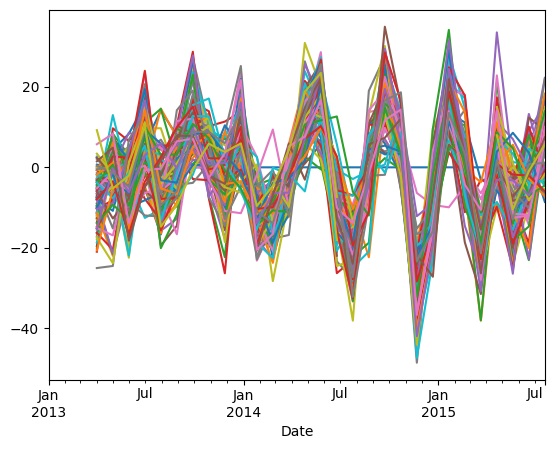

In [115]:
slopes[np.arange(1, 100)].plot(legend=None)

In [ ]:
import matplotlib.pyplot as plt 

plt.plos(slopes[])

In [71]:
slopes[1]

Date
2013-01-01          NaN
2013-02-15   -68.767232
2013-04-01   -26.446414
2013-05-16    12.938411
2013-06-30     4.600093
2013-08-14    -4.382195
2013-09-28     8.678619
2013-11-12     1.596095
2013-12-27    12.515016
2014-02-10   -26.098514
2014-03-27     3.040577
2014-05-11     8.316996
2014-06-25    -4.632622
2014-08-09   -13.062446
2014-09-23    14.258213
2014-11-07    -1.046034
2014-12-22   -12.211318
2015-02-05    11.866205
2015-03-22   -28.570667
2015-05-06     1.697423
2015-06-20    -2.986975
Name: 1, dtype: float64

In [8]:
# Extract components
rolled["year"] = rolled.index.year
rolled["quarter"] = rolled.index.quarter
rolled["month"] = rolled.index.month
rolled["week"] = rolled.index.isocalendar().week     # ISO week number

# Extract components
rolled["day_of_week"]   = rolled.index.dayofweek      # Monday=0, Sunday=6
rolled["day_of_month"]  = rolled.index.day
rolled["day_of_year"]   = rolled.index.dayofyear

# For day of quarter, compute relative to quarter start
quarter_start_day = rolled.index.to_period("Q").start_time
rolled["day_of_quarter"] = (rolled.index - quarter_start_day).days + 1


<Axes: xlabel='Date'>

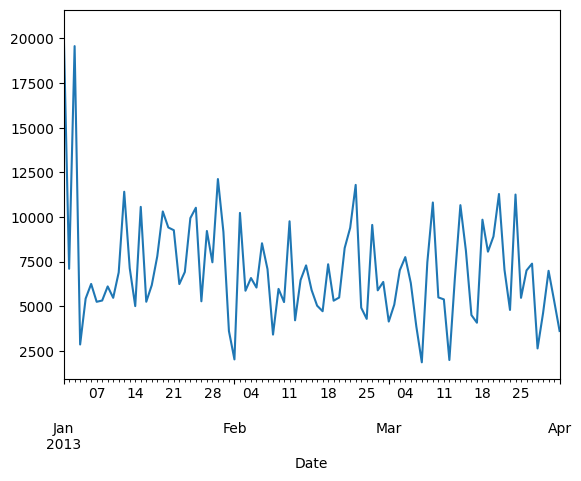

In [9]:
rolled[1].plot()